In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("MiningProcess_Flotation_Plant_Database.csv", on_bad_lines='skip')

df.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,"55,2","16,98","3019,53","557,434","395,713","10,0664","1,74","249,214","253,235",...,"250,884","457,396","432,962","424,954","443,558","502,255","446,37","523,344","66,91","1,31"
1,2017-03-10 01:00:00,"55,2","16,98","3024,41","563,965","397,383","10,0672","1,74","249,719","250,532",...,"248,994","451,891","429,56","432,939","448,086","496,363","445,922","498,075","66,91","1,31"
2,2017-03-10 01:00:00,"55,2","16,98","3043,46","568,054","399,668","10,068","1,74","249,741","247,874",...,"248,071","451,24","468,927","434,61","449,688","484,411","447,826","458,567","66,91","1,31"
3,2017-03-10 01:00:00,"55,2","16,98","3047,36","568,665","397,939","10,0689","1,74","249,917","254,487",...,"251,147","452,441","458,165","442,865","446,21","471,411","437,69","427,669","66,91","1,31"
4,2017-03-10 01:00:00,"55,2","16,98","3033,69","558,167","400,254","10,0697","1,74","250,203","252,136",...,"248,928","452,441","452,9","450,523","453,67","462,598","443,682","425,679","66,91","1,31"


Foi utilizado o parâmetro on_bad_lines='skip' para ignorar linhas com erros no arquivo CSV.
Essas inconsistências podem ocorrer em dados reais devido a falhas na coleta ou exportação.
A remoção dessas linhas permite continuar a análise sem comprometer significativamente os resultados.


In [5]:
df.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,"55,2","16,98","3019,53","557,434","395,713","10,0664","1,74","249,214","253,235",...,"250,884","457,396","432,962","424,954","443,558","502,255","446,37","523,344","66,91","1,31"
1,2017-03-10 01:00:00,"55,2","16,98","3024,41","563,965","397,383","10,0672","1,74","249,719","250,532",...,"248,994","451,891","429,56","432,939","448,086","496,363","445,922","498,075","66,91","1,31"
2,2017-03-10 01:00:00,"55,2","16,98","3043,46","568,054","399,668","10,068","1,74","249,741","247,874",...,"248,071","451,24","468,927","434,61","449,688","484,411","447,826","458,567","66,91","1,31"
3,2017-03-10 01:00:00,"55,2","16,98","3047,36","568,665","397,939","10,0689","1,74","249,917","254,487",...,"251,147","452,441","458,165","442,865","446,21","471,411","437,69","427,669","66,91","1,31"
4,2017-03-10 01:00:00,"55,2","16,98","3033,69","558,167","400,254","10,0697","1,74","250,203","252,136",...,"248,928","452,441","452,9","450,523","453,67","462,598","443,682","425,679","66,91","1,31"


In [7]:
df.shape

(737453, 24)

In [8]:
df.info() # Aqui fazemos um raio-x do nosso banco de dados, pelo shape constatamos ser um banco de dados muito grande.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   date                          737453 non-null  object
 1   % Iron Feed                   737453 non-null  object
 2   % Silica Feed                 737453 non-null  object
 3   Starch Flow                   737453 non-null  object
 4   Amina Flow                    737453 non-null  object
 5   Ore Pulp Flow                 737453 non-null  object
 6   Ore Pulp pH                   737453 non-null  object
 7   Ore Pulp Density              737453 non-null  object
 8   Flotation Column 01 Air Flow  737453 non-null  object
 9   Flotation Column 02 Air Flow  737453 non-null  object
 10  Flotation Column 03 Air Flow  737453 non-null  object
 11  Flotation Column 04 Air Flow  737453 non-null  object
 12  Flotation Column 05 Air Flow  737453 non-null  object
 13 

Constatamos que os números não são números por isso não dá pra calcular direito, os gráficos podem dar erro e a correlação não funciona , o que implica que o dataset ainda NÃO está pronto pra análise. Assim vamos aplicar alguns tratamentos.

In [9]:
# remover vírgula e trocar por ponto
df = df.replace(',', '.', regex=True)

# converter colunas (exceto data)
for col in df.columns:
    if col != 'date':
        df[col] = pd.to_numeric(df[col], errors='coerce')

Vamos concertar a data.

In [10]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [11]:
df.dtypes

,0
date,datetime64[ns]
% Iron Feed,float64
% Silica Feed,float64
Starch Flow,float64
Amina Flow,float64
Ore Pulp Flow,float64
Ore Pulp pH,float64
Ore Pulp Density,float64
Flotation Column 01 Air Flow,float64
Flotation Column 02 Air Flow,float64


Como visto  foram feitas a limpeza de dados o tratamento de formato a padronização e preparação pra análise.

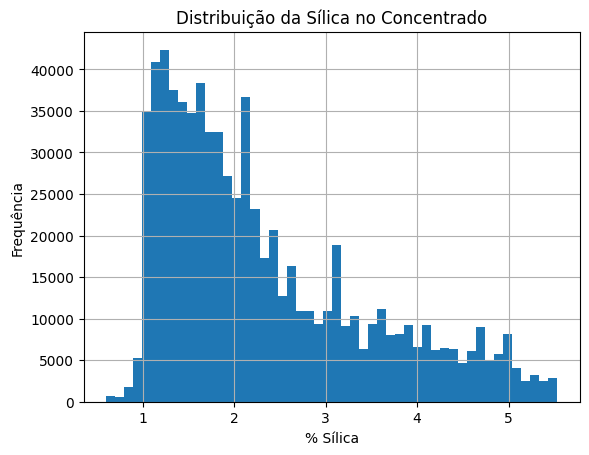

In [12]:
import matplotlib.pyplot as plt              # Com essa biblioteca podemos fazer gráficos e analisar padrões e discrepâncias.

df["% Silica Concentrate"].hist(bins=50)
plt.title("Distribuição da Sílica no Concentrado")
plt.xlabel("% Sílica")
plt.ylabel("Frequência")
plt.show()

### A distribuição da sílica no concentrado apresenta maior concentração entre 1% e 2.5%, indicando o padrão operacional da planta. No entanto, observa-se uma cauda longa com valores acima de 4%, sugerindo possíveis eventos de instabilidade ou condições operacionais fora do ideal.

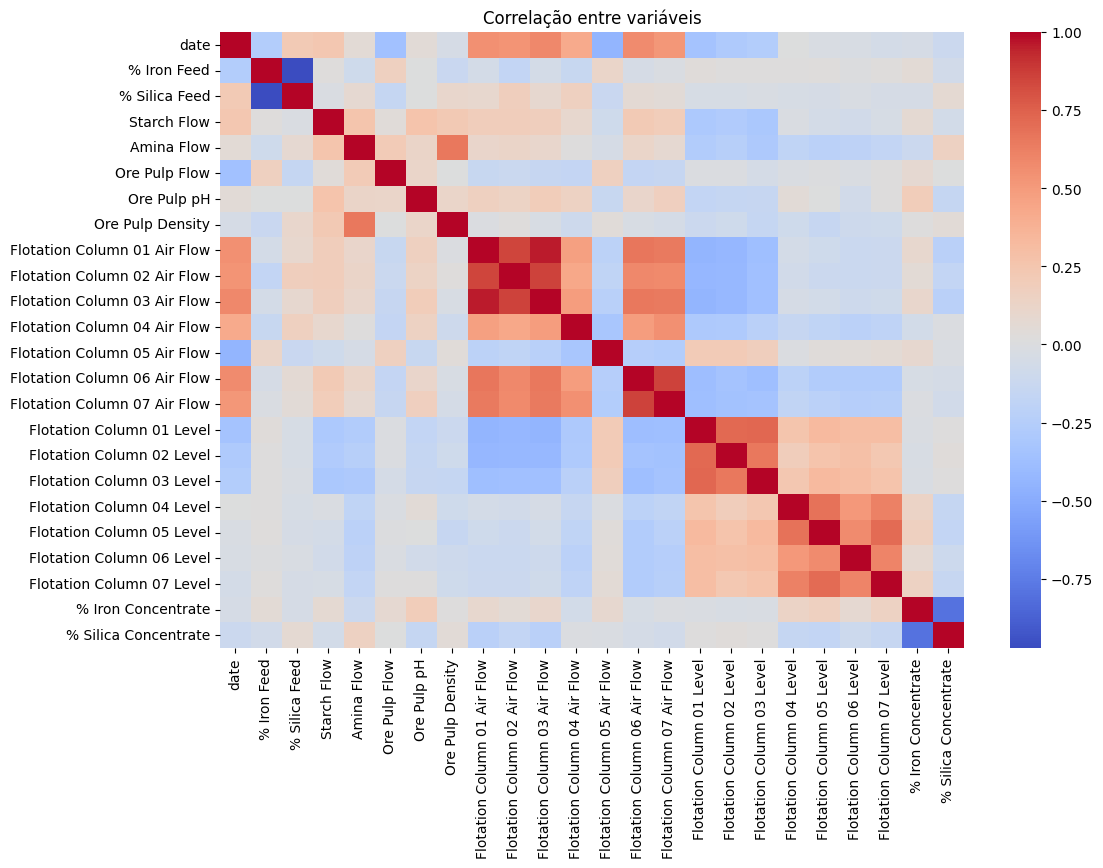

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlação entre variáveis")
plt.show()

### Observa-se forte correlação negativa entre o teor de ferro e a concentração de sílica, indicando que o aumento da pureza do minério está diretamente associado à redução de impurezas. Além disso, variáveis operacionais como níveis e fluxo de ar nas colunas de flotação apresentam alta correlação entre si, sugerindo comportamento integrado do sistema.

In [14]:
df.corr()["% Silica Concentrate"].sort_values(ascending=False)

,% Silica Concentrate
% Silica Concentrate,1.000000
Amina Flow,0.156701
% Silica Feed,0.072724
Ore Pulp Density,0.046984
Flotation Column 02 Level,0.030955
Flotation Column 01 Level,0.017217
Flotation Column 03 Level,0.014246
Ore Pulp Flow,0.008222
Flotation Column 04 Air Flow,-0.005011
Flotation Column 05 Air Flow,-0.009293


###Observa-se forte correlação negativa (-0.80) entre o teor de ferro e a sílica no concentrado, indicando que o aumento da pureza do minério está diretamente associado à redução de impurezas, validando o comportamento esperado do processo de flotação.

<Axes: xlabel='Ore Pulp pH', ylabel='% Silica Concentrate'>

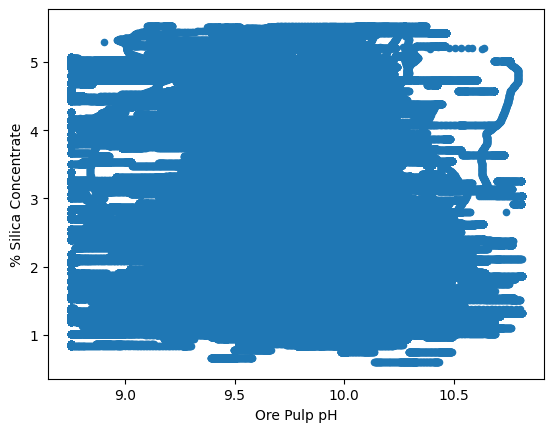

In [15]:
df.plot.scatter(x="Ore Pulp pH", y="% Silica Concentrate")

###O gráfico de dispersão entre pH e concentração de sílica não apresenta uma relação visual clara, indicando baixa correlação entre as variáveis.

<Axes: xlabel='Flotation Column 01 Air Flow', ylabel='% Silica Concentrate'>

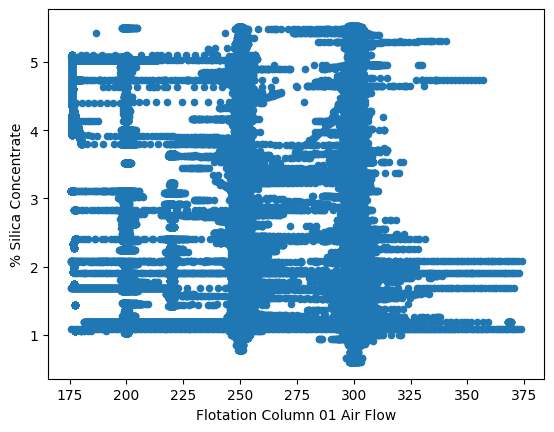

In [16]:
df.plot.scatter(x="Flotation Column 01 Air Flow", y="% Silica Concentrate")

###Observa-se maior concentração de dados na faixa entre 250 e 300 no fluxo de ar da coluna de flotação, indicando que este é o intervalo mais frequente de operação do processo.

<Axes: xlabel='% Iron Concentrate', ylabel='% Silica Concentrate'>

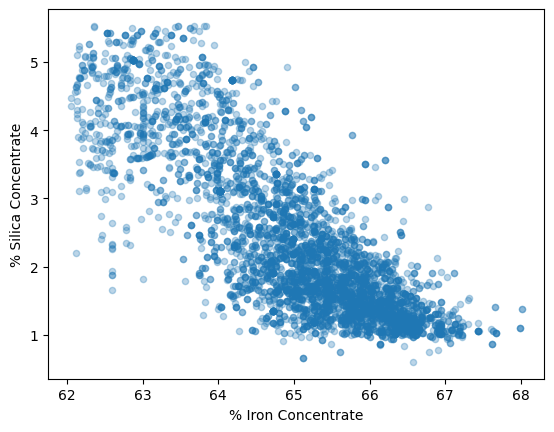

In [17]:
sample = df.sample(5000)

sample.plot.scatter(
    x="% Iron Concentrate",
    y="% Silica Concentrate",
    alpha=0.3
)

###O gráfico de dispersão entre o teor de ferro e a concentração de sílica apresenta uma relação inversa bem definida, onde o aumento do teor de ferro está associado à redução da sílica. Esse comportamento está alinhado com o objetivo do processo de flotação, que visa maximizar a pureza do minério.


#Conclusão

Ao longo da análise, foram realizadas etapas fundamentais como tratamento de dados, correção de inconsistências (como valores com vírgula decimal), conversão de tipos e exploração estatística. A partir disso, foi possível desenvolver uma análise exploratória consistente, utilizando gráficos e correlações para identificar padrões relevantes no processo.

Os resultados demonstraram uma forte relação inversa entre o teor de ferro e a concentração de sílica, evidenciando o comportamento esperado do processo de flotação. Além disso, variáveis operacionais como fluxo de ar, pH e níveis das colunas apresentaram influência no resultado final, ainda que de forma moderada, indicando que o desempenho do processo depende de um conjunto de fatores interligados.

Outro ponto importante foi a identificação de padrões operacionais, como faixas de funcionamento mais frequentes, o que reforça a existência de controle e estabilidade no processo industrial analisado.

Durante minha experiência na indústria, tive contato com o processo de flotação, onde pude observar na prática o funcionamento dos tanques, a adição de reagentes e a dinâmica da separação do minério. Essa vivência contribuiu diretamente para uma melhor interpretação dos dados, permitindo conectar a análise teórica com situações reais do ambiente industrial.

Dessa forma, este projeto não apenas demonstra habilidades técnicas em análise de dados, mas também evidencia a capacidade de compreender e interpretar processos industriais complexos, unindo conhecimento prático e analítico para geração de insights relevantes.